# House Price Prediction
## Objective:
#### Build regression models to predict house prices using housing features and identify the factors that most influence property value.

# Import Libraries

In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.pipeline import Pipeline

import joblib

# Task 1 — Data Loading & Exploration

In [2]:
# Load Dataset
df = pd.read_csv("..\Data\Housing.csv")

# Load Dataset
df.head(10)

In [3]:
# Shape of Data
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [4]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


The dataset contains both numerical and categorical variables that can influence house prices.

In [5]:
# Missing Values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing values were found in the dataset, indicating good data quality.

In [6]:
# Duplicate Values
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


No duplicate records were found, so no duplicate removal was required.

In [7]:
# Statistical Summary
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


House prices and property areas show considerable variation, suggesting diverse property characteristics.

In [8]:
# Understand the Target and Feature Columns
target = df['price']
features= df.drop('price', axis=1)

In [9]:
target.sample(5)

72     6720000
229    4690000
497    2660000
115    6020000
143    5600000
Name: price, dtype: int64

In [10]:
features.sample(5)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
132,5200,3,1,3,yes,no,no,no,yes,0,no,semi-furnished
238,4510,4,2,2,yes,no,yes,no,no,0,no,semi-furnished
360,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
505,4000,3,1,2,yes,no,no,no,yes,0,no,unfurnished
198,5948,3,1,2,yes,no,no,no,yes,0,no,semi-furnished


# Task 4 — Visualization

### I performed data visualization before cleaning the dataset because it helped me understand the data distribution, identify missing values, detect outliers, and uncover patterns or anomalies. This allowed me to make informed preprocessing decisions and apply appropriate data cleaning techniques rather than modifying the data without understanding its characteristics.

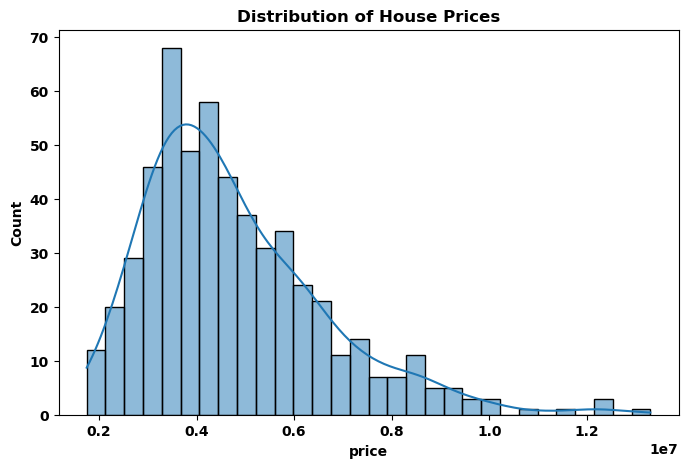

In [11]:
# Distribution of House Prices
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.savefig(
    "../Charts/price_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

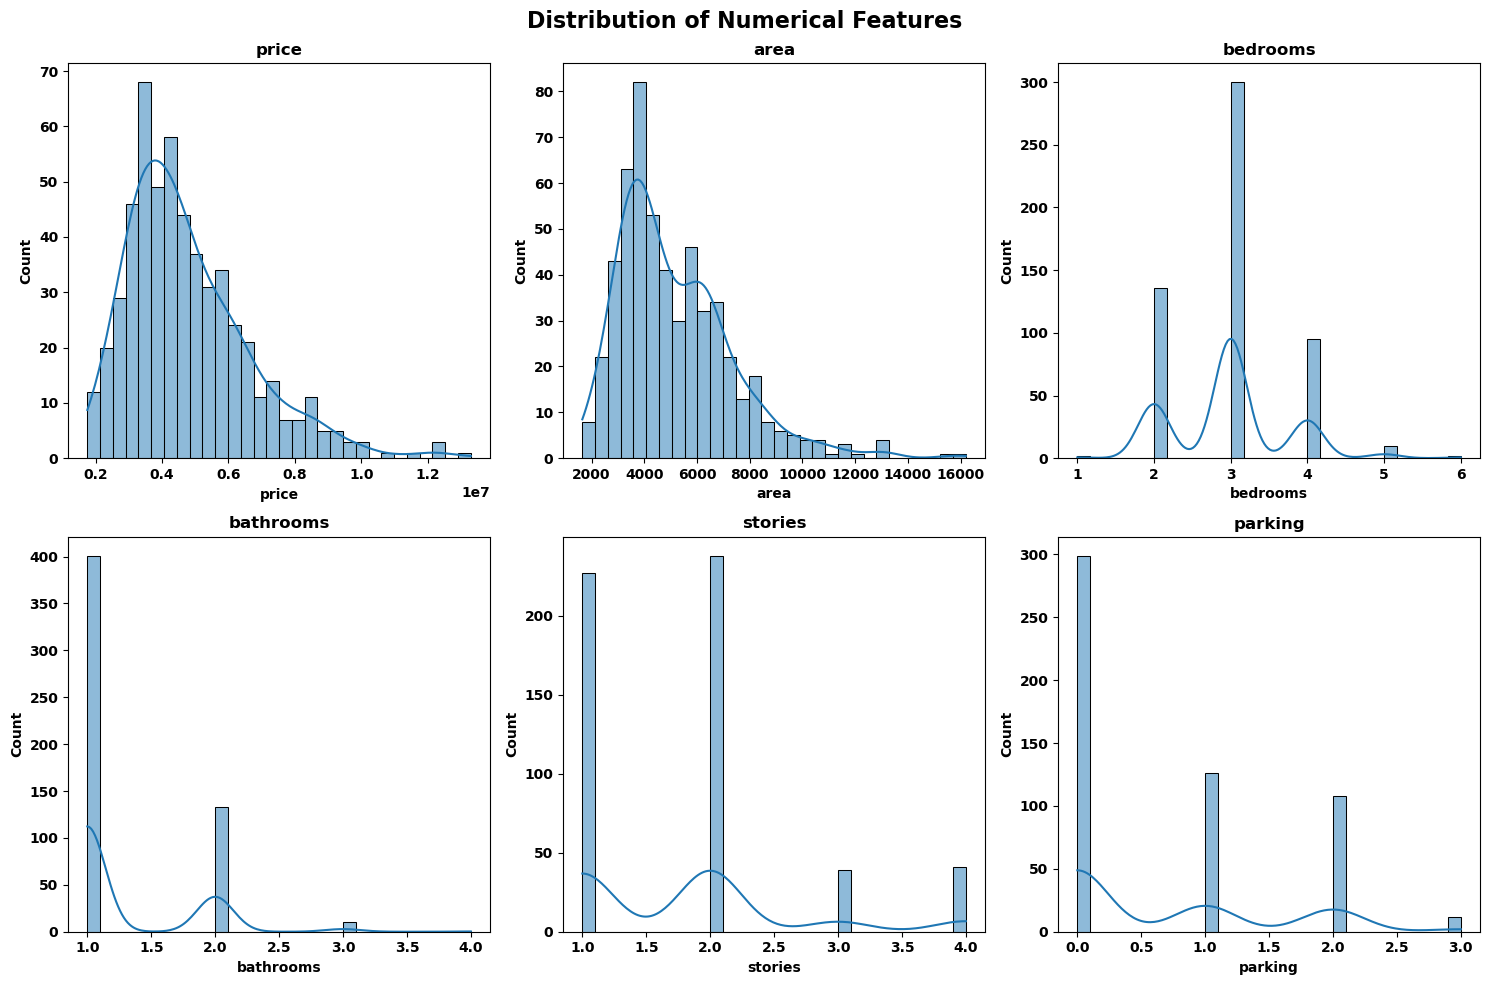

In [12]:
# Distributionof Numerical Feature
num_cols = ['price', 'area', 'bedrooms', 'bathrooms',
            'stories', 'parking']

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

# Save chart
plt.savefig("../Charts/numerical_features_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

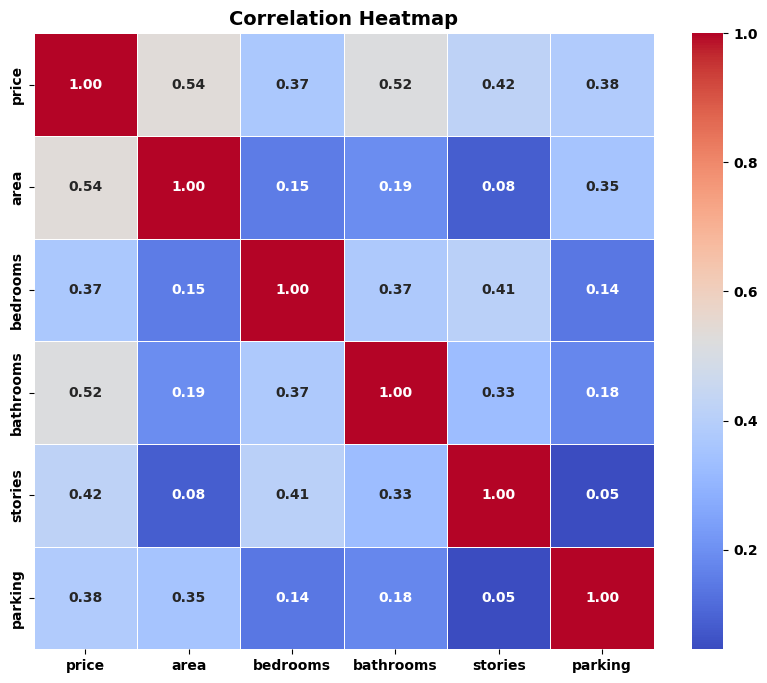

In [13]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)

# Save chart
plt.savefig(
    "../Charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

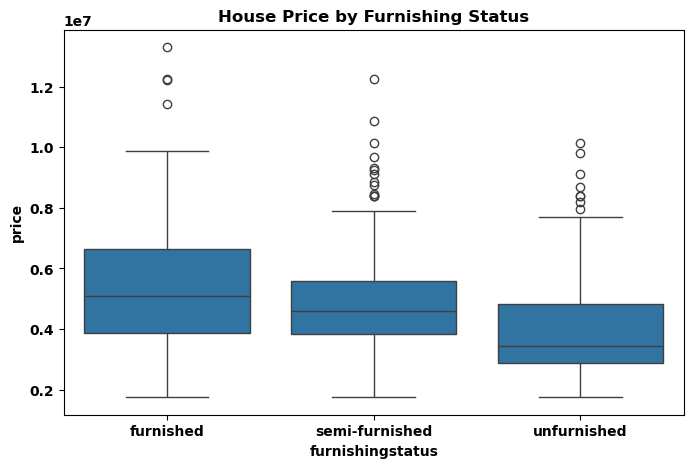

In [14]:
# House Price by Furnishing Status
plt.figure(figsize=(8,5))

sns.boxplot(
    x='furnishingstatus',
    y='price',
    data=df
)

plt.title("House Price by Furnishing Status")

plt.savefig("../Charts/furnishing_status_price.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

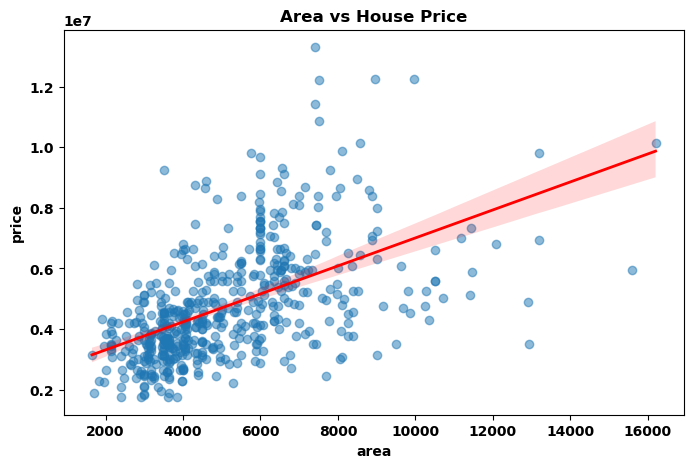

In [15]:
# Area VS House Price
plt.figure(figsize=(8,5))

sns.regplot(
    x='area',
    y='price',
    data=df,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Area vs House Price")

plt.savefig(
    "../Charts/area_vs_price.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

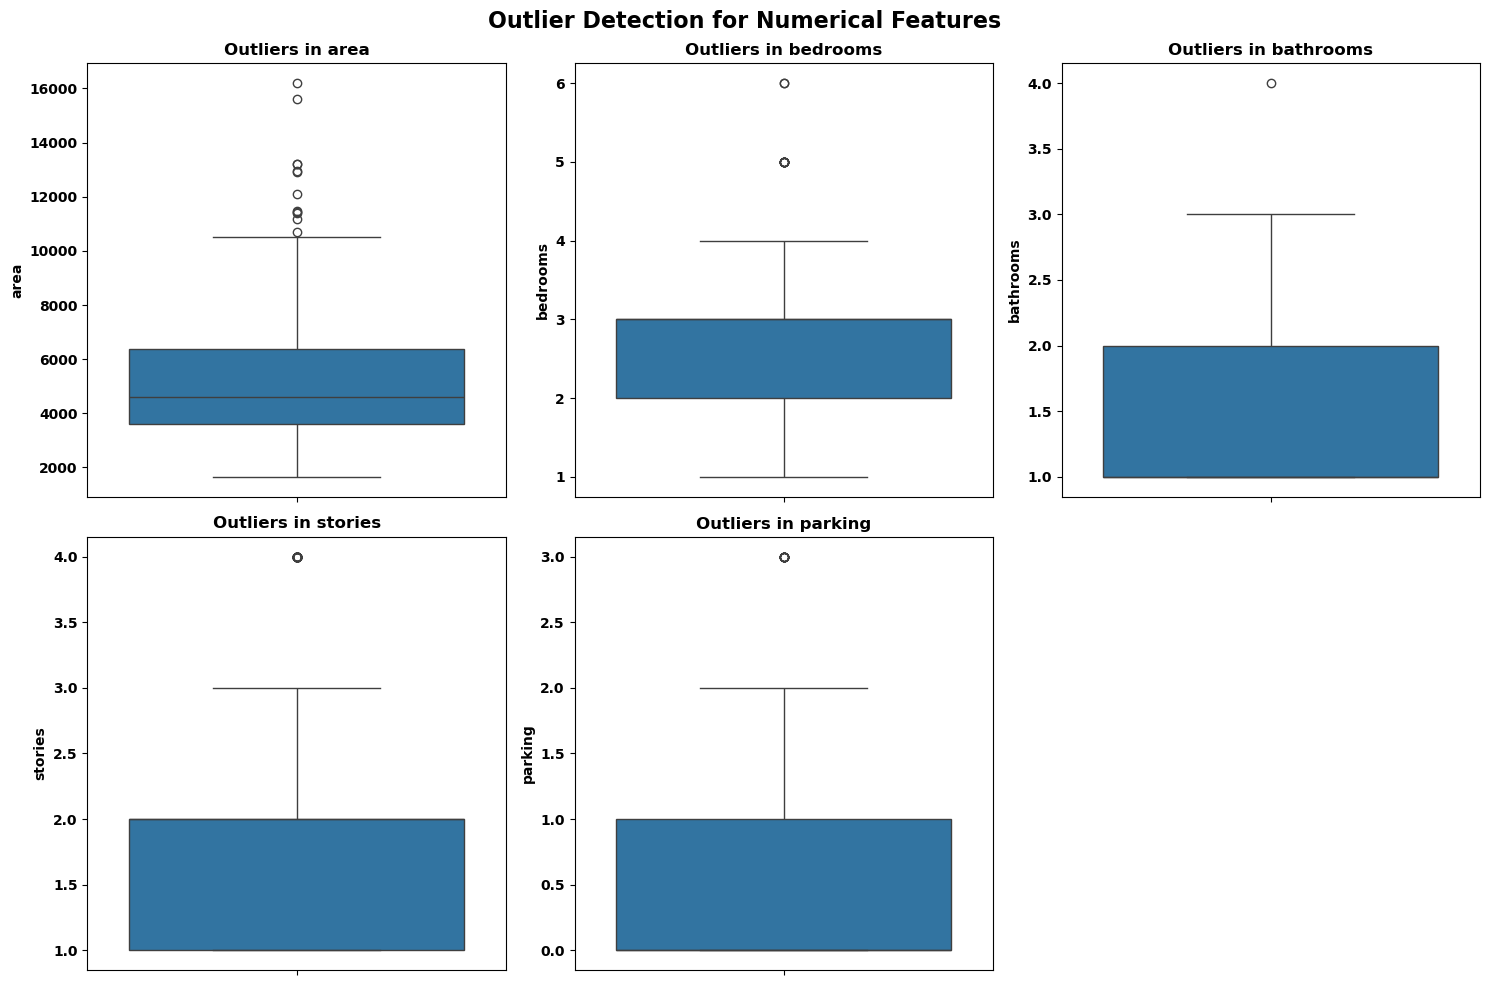

In [62]:
# Outlier Detection for Numerical Column
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')

plt.suptitle("Outlier Detection for Numerical Features", fontsize=16)
plt.tight_layout()

plt.savefig(
    "../Charts/outlier_detection_boxplots.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Task 2 — Data Cleaning

In [17]:
df_clean = df.copy()
# A copy of the original dataset was created to preserve the raw data for future reference.

In [63]:
# Saperated Categorical Column
cat_cols = df_clean.select_dtypes(
    include='str'
).columns

print(cat_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [26]:
# Dose a One Hot Encoding and StandardScaler
num_cols = ['area', 'bedrooms', 'bathrooms',
            'stories', 'parking']
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ],
    remainder='passthrough'
)

### No missing values were found in the dataset. Therefore, no imputation or data filling techniques were required, ensuring that all records could be used for model training.
------------------

### No duplicate records were identified in the dataset. This indicates that each observation is unique and no duplicate removal was necessary.
-------------------------------------

### Feature selection was not performed initially because the dataset contains only relevant housing attributes. Using all available features allows the model to capture complete property characteristics while feature importance analysis helps identify the most influential predictors after training.

# Task 3 — Model Building

In [64]:
# Separated Feature or Label Column
X = df_clean.drop('price', axis=1)
y = np.log1p(df['price'])
# The target variable is house price, while all remaining housing attributes are used as predictor variables.

In [65]:
# Train , Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (436, 12)
Testing Shape: (109, 12)


### The dataset was divided into training and testing sets using an 80:20 ratio. This allows the model to learn patterns from training data and evaluate performance on unseen data.

In [87]:
# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression(
    ))
])

In [88]:
# Fit Data On Linear Regression
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [89]:
# Predict Output for Linear Regression
y_pred_lr = lr_pipeline.predict(X_test)

In [90]:
# Find MAE , RMSE , R2 Score for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
MAE : 0.19990267828472952
RMSE: 0.25158207601324634
R²  : 0.6722047416501273


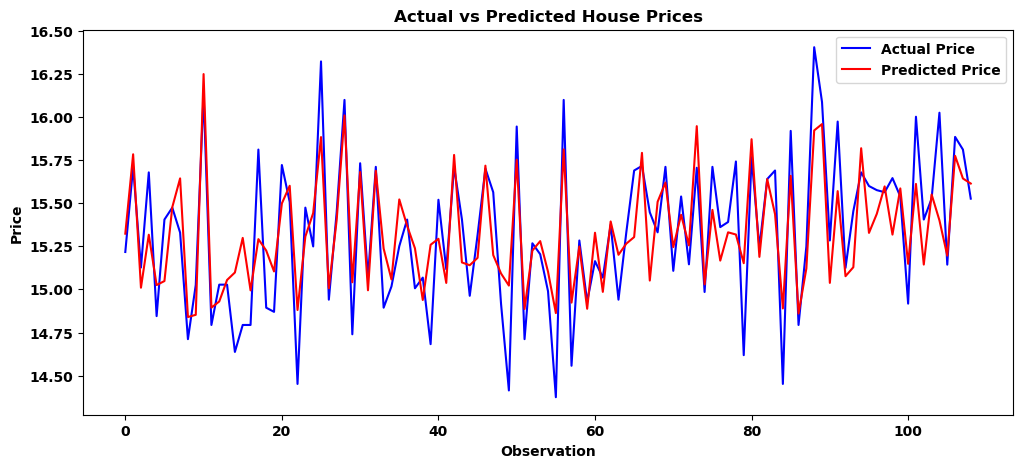

In [91]:
# Linear Regression: Actual vs Predicted Prices Graphical Representation
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    color='blue',
    label='Actual Price'
)

plt.plot(
    y_pred_lr,
    color='red',
    label='Predicted Price'
)

plt.xlabel("Observation")
plt.ylabel("Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()

plt.savefig(
    "../Charts/actual_vs_predicted_linear_regression.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [92]:
# Save Linear Regression Model
joblib.dump(
    lr_pipeline,
    "../Models/linear_regression_model.pkl"
)

print("Linear Regression model saved.")

Linear Regression model saved.


In [93]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ],
    remainder='passthrough'
)

In [94]:
# RandomForest Regressor Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
))
])

# Fit Data On RandomForest Regressor
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [95]:
# Predict Output for RandomForest Regressor
y_pred_rf = rf_pipeline.predict(X_test)

In [96]:
# Find MAE , RMSE , R2 Score for  RandomForest Regressor
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print(f"MAE  : {mae_rf}")
print(f"RMSE : {rmse_rf}")
print(f"R²   : {r2_rf}")

Random Forest Results
MAE  : 0.20959776418917175
RMSE : 0.2671106696820982
R²   : 0.6304903826703205


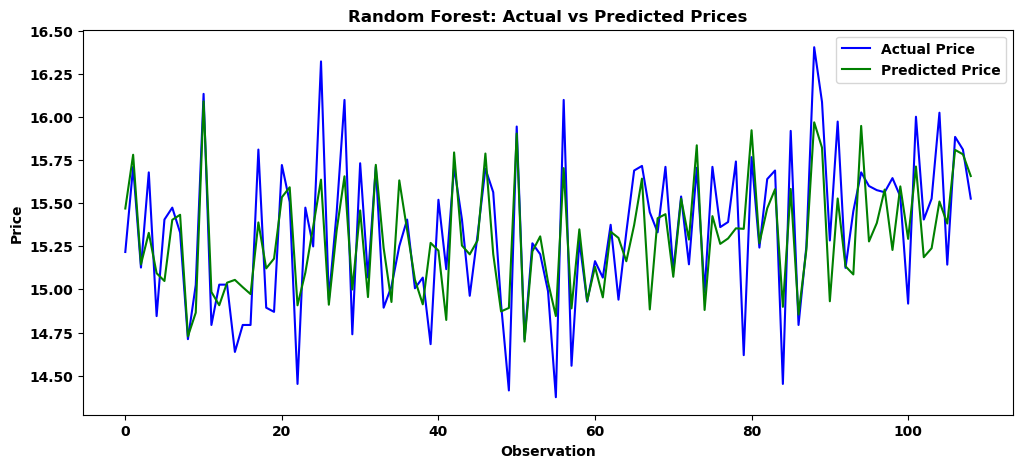

In [97]:
# Random Forest: Actual vs Predicted Prices Graphical Representation
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    color='blue',
    label='Actual Price'
)

plt.plot(
    y_pred_rf,
    color='green',
    label='Predicted Price'
)

plt.xlabel("Observation")
plt.ylabel("Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.legend()

plt.savefig(
    "../Charts/random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [98]:
# Save Random Forest Model
joblib.dump(
    rf_pipeline,
    "../Models/random_forest_model.pkl"
)

print("Random Forest model saved.")

Random Forest model saved.


In [99]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

comparison = comparison.round(4)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.1999,0.2516,0.6722
1,Random Forest,0.2096,0.2671,0.6305


<Figure size 1000x600 with 0 Axes>

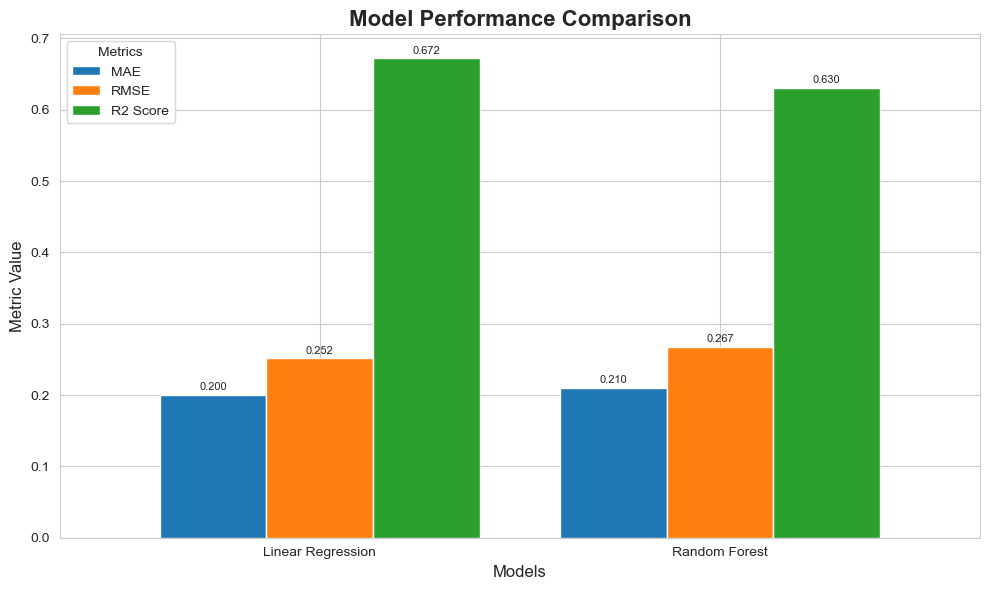

In [104]:
# Model Performance Comparison
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

ax = metrics_df.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8
)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Models", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Metrics")

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        fontsize=8,
        padding=2
    )

plt.tight_layout()

plt.savefig(
    "../Charts/model_performance_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Task 5 — Insights & Summary

##  Based on the correlation heatmap and model analysis, area (sq. ft.) is the strongest driver of house price. The number of bathrooms and bedrooms rank next, followed by stories and parking. Location attributes such as being in a preferred area and having main road access also add meaningful value, while amenities like air conditioning and basement presence contribute at a smaller scale.
-----------------------------

## Linear Regression explained 67.2% of house price variation (R2 = 0.6722), a reasonable result for real housing data.
## Random Forest achieved 63.0% (R2 = 0.6305), slightly lower — confirming that price relationships here are largely linear.
-------------------

## Both models achieved similar R2 scores (~63–67%), indicating house prices are influenced by factors beyond the available features such as neighbourhood sentiment or market timing. It was also surprising that Linear Regression outperformed Random Forest, and that the dataset had zero missing values and zero duplicates — rare in real-world data.
-----------

## Prioritize larger properties in preferred locations with main road access, as area and location are the dominant price drivers. To improve model accuracy beyond 67%, enrich the dataset with features like proximity to schools, market trends, or neighbourhood ratings before deploying any automated valuation tool.
---------